In [19]:



import pandas as pd
import boto3
from dotenv import load_dotenv
import os
from pycaret.regression import setup, compare_models, finalize_model, plot_model, save_model, load_model, predict_model,pull
from botocore.config import Config
import io
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns


df1 = pd.read_csv('halfmarathon_wroclaw_2023__final.csv', sep=';')
df2=pd.read_csv('halfmarathon_wroclaw_2024__final.csv', sep=";")




In [20]:
#inicjuje połaczemnie z chmura
load_dotenv()

BUCKET_NAME= 'gotoitwaldek'


s3 = boto3.client(
    's3',
    aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('AWS_SECRET_ACCES_KEY'),
    endpoint_url=os.getenv("AWS_ENDPOINT_URL_S3"),
    config=Config(signature_version='s3v4')
)


In [21]:
# Przesyłanie plików do Digital Ocean Spaces
session = boto3.session.Session()
client = session.client('s3',
                        aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'),
                        aws_secret_access_key=os.getenv('AWS_SECRET_ACCES_KEY'),
                        endpoint_url=os.getenv("AWS_ENDPOINT_URL_S3"),
                        config=Config(signature_version='s3v4')
                        )


# Przesyłanie pierwszego pliku
client.upload_file('halfmarathon_wroclaw_2023__final.csv', BUCKET_NAME, 'halfmarathon_wroclaw_2023__final.csv')
print('Przesłano: halfmarathon_wroclaw_2023__final.csv')

# Przesyłanie drugiego pliku
client.upload_file('halfmarathon_wroclaw_2024__final.csv', BUCKET_NAME, 'halfmarathon_wroclaw_2024__final.csv')
print('Przesłano: halfmarathon_wroclaw_2024__final.csv')


Przesłano: halfmarathon_wroclaw_2023__final.csv
Przesłano: halfmarathon_wroclaw_2024__final.csv


In [22]:

# Listowanie obiektów w buckecie
def list_objects_in_bucket():
    try:
        response = client.list_objects_v2(Bucket=BUCKET_NAME)
        if 'Contents' in response:
            print("Pliki w buckecie:")
            for obj in response['Contents']:
                print(f"- {obj['Key']}")
        else:
            print(f"Bucket {BUCKET_NAME} jest pusty lub nie istnieje.")
    except Exception as e:
        print(f"Błąd podczas listowania obiektów: {e}")

list_objects_in_bucket()


Pliki w buckecie:
- halfmarathon_wroclaw_2023__final.csv
- halfmarathon_wroclaw_2024__final.csv


In [23]:
# 1. Pobierz obiekty używając SAMYCH nazw plików jako Key
response_2023 = client.get_object(Bucket=BUCKET_NAME, Key='halfmarathon_wroclaw_2023__final.csv')
response_2024 = client.get_object(Bucket=BUCKET_NAME, Key='halfmarathon_wroclaw_2024__final.csv')

# 2. Wczytaj do Pandas (używamy io.BytesIO, aby zamienić strumień bajtów na czytelny plik)
df_2023 = pd.read_csv(io.BytesIO(response_2023['Body'].read()), sep=';')
df_2024 = pd.read_csv(io.BytesIO(response_2024['Body'].read()), sep=';')

# 3. Połącz tabele
df = pd.concat([df_2023, df_2024], ignore_index=True)

# 4. Sprawdzenie wyniku
print(f"✅ Sukces! Wczytano łącznie {len(df)} rekordów.")
print(df.head(10))



✅ Sukces! Wczytano łącznie 21957 rekordów.
   Miejsce  Numer startowy       Imię       Nazwisko      Miasto Kraj  \
0      1.0            1787     TOMASZ         GRYCKO         NaN  POL   
1      2.0               3  ARKADIUSZ  GARDZIELEWSKI     WROCŁAW  POL   
2      3.0            3832  KRZYSZTOF          HADAS      POZNAŃ  POL   
3      4.0             416     DAMIAN         DYDUCH       KĘPNO  POL   
4      5.0            8476      KAMIL      MAŃKOWSKI      MIRKÓW  POL   
5      6.0            2551       ADAM         PUTYRA     WROCŁAW  POL   
6      7.0            1288     MICHAŁ         WÓJCIK    KROŚNICE  POL   
7      8.0            7837     PATRYK    CHRZANOWSKI     BIELAWA  POL   
8      9.0            5657    CYPRIAN        GRZELKA  POGRZEBIEŃ  POL   
9     10.0            5927       ADAM      KONIECZNY   ZANIEMYSL  POL   

                          Drużyna Płeć  Płeć Miejsce Kategoria wiekowa  ...  \
0          UKS BLIZA WŁADYSŁAWOWO    M           1.0               M30  ..

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21957 entries, 0 to 21956
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Miejsce                    18450 non-null  float64
 1   Numer startowy             21957 non-null  int64  
 2   Imię                       21957 non-null  object 
 3   Nazwisko                   21957 non-null  object 
 4   Miasto                     17774 non-null  object 
 5   Kraj                       18450 non-null  object 
 6   Drużyna                    8402 non-null   object 
 7   Płeć                       21946 non-null  object 
 8   Płeć Miejsce               18450 non-null  float64
 9   Kategoria wiekowa          21926 non-null  object 
 10  Kategoria wiekowa Miejsce  18430 non-null  float64
 11  Rocznik                    21472 non-null  float64
 12  5 km Czas                  18411 non-null  object 
 13  5 km Miejsce Open          18411 non-null  flo

In [27]:
#gdzie brakuje danych
df.isna().sum()/len(df)*100

Miejsce                      15.972127
Numer startowy                0.000000
Imię                          0.000000
Nazwisko                      0.000000
Miasto                       19.050872
Kraj                         15.972127
Drużyna                      61.734299
Płeć                          0.050098
Płeć Miejsce                 15.972127
Kategoria wiekowa             0.141185
Kategoria wiekowa Miejsce    16.063214
Rocznik                       2.208863
5 km Czas                    16.149747
5 km Miejsce Open            16.149747
5 km Tempo                   16.149747
10 km Czas                   16.076878
10 km Miejsce Open           16.076878
10 km Tempo                  16.222617
15 km Czas                   16.072323
15 km Miejsce Open           16.072323
15 km Tempo                  16.140639
20 km Czas                   16.022225
20 km Miejsce Open           16.022225
20 km Tempo                  16.099649
Tempo Stabilność             16.304595
Czas                     

In [28]:
len(df.dropna())/len(df)*100

31.921482898392313

In [29]:
# Define a function to convert a time string into seconds
def convert_time_to_seconds(time):
    # Check if the time is null or has values indicating "Did Not Start (DNS)" or "Did Not Finish (DNF)"
    if pd.isnull(time) or time in ['DNS', 'DNF']:
        return None  # Return None if the value is missing or if it’s DNS or DNF

    # Ensure the value is a string before attempting to split
    if not isinstance(time, str):
        return None  # Return None if the value is not a string (to prevent errors)

    # Split the time string into hours, minutes, and seconds
    try:
        time_parts = time.split(':')
        # Convert hours, minutes, and seconds to total seconds and return
        return int(time_parts[0]) * 3600 + int(time_parts[1]) * 60 + int(time_parts[2])
    except (IndexError, ValueError):
        # Handle cases where the time string is not in the expected format
        return None

# List of columns in the DataFrame that contain time information
columns = ['Czas', '5 km Czas', '10 km Czas', '15 km Czas', '20 km Czas']

# Iterate over each column in the list
for col in columns:
    # Apply the `convert_time_to_seconds` function to each element in the column
    df[col] = df[col].apply(convert_time_to_seconds)

# Print the updated DataFrame to check the result
df.sample(5)

,Miejsce,Numer startowy,Imię,Nazwisko,Miasto,Kraj,Drużyna,Płeć,Płeć Miejsce,Kategoria wiekowa,...,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
11180,2231.0,4212,MARCIN,MARCHEWKA,ZLOTORYJA,POL,NaN,M,2026.0,M20,...,4.90,4530.0,2303.0,5.153333,6153.0,2297.0,5.41,0.026867,6494.0,5.130758
12862,3913.0,5954,TOMASZ,GAWĘDA,KNURÓW,POL,ING BANK ŚLĄSKI,M,3398.0,M30,...,5.25,4850.0,3749.0,5.483333,6599.0,3869.0,5.83,0.028467,7000.0,5.530536
21711,NaN,24012,MAREK,WOJNACKI,NaN,NaN,NaN,M,NaN,M40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8230,NaN,3351,ARKADIUSZ,CHOWAŃSKI,NaN,NaN,Ssp Strus,M,NaN,M30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20678,NaN,6372,DOMINIK,MIELCAREK,NaN,NaN,NaN,M,NaN,M40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
df=df[['Płeć', 'Rocznik','Kategoria wiekowa','5 km Czas', 'Czas']]
df

,Płeć,Rocznik,Kategoria wiekowa,5 km Czas,Czas
0,M,1992.0,M30,877.0,3899.0
1,M,1986.0,M30,888.0,3983.0
2,M,1996.0,M20,946.0,4104.0
3,M,1988.0,M30,971.0,4216.0
4,M,1995.0,M20,972.0,4227.0
...,...,...,...,...,...
21952,K,1982.0,K40,NaN,NaN
21953,K,1998.0,K20,NaN,NaN
21954,M,1995.0,M20,NaN,NaN
21955,K,1991.0,K30,NaN,NaN


In [37]:
df.isna().sum()

Płeć                 0
Rocznik              0
Kategoria wiekowa    0
5 km Czas            0
Czas                 0
dtype: int64

In [35]:
#usuwanie wartosci brakujacych z wybranyc kolumn
df = df.dropna(subset=['Płeć','Rocznik', 'Kategoria wiekowa'])

In [36]:

df = df.fillna(df.median(numeric_only=True))
df

,Płeć,Rocznik,Kategoria wiekowa,5 km Czas,Czas
0,M,1992.0,M30,877.0,3899.0
1,M,1986.0,M30,888.0,3983.0
2,M,1996.0,M20,946.0,4104.0
3,M,1988.0,M30,971.0,4216.0
4,M,1995.0,M20,972.0,4227.0
...,...,...,...,...,...
21952,K,1982.0,K40,1663.0,7256.0
21953,K,1998.0,K20,1663.0,7256.0
21954,M,1995.0,M20,1663.0,7256.0
21955,K,1991.0,K30,1663.0,7256.0


# Model z nietknietymi oulinersami

In [16]:
from sklearn.decomposition import PCA

# Praca z outlinersami
## przy pomocy Pycaret

In [12]:
[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_all[(df_all[col] < Q1 - 1.5*IQR) | (df_all[col] > Q3 + 1.5*IQR)]
    outliers_summary[col] = [len(outliers)]

print("Liczba outliersów w każdej kolumnie:")
print(outliers_summary)

IndentationError: unexpected indent (463330640.py, line 2)

In [26]:
# przy 
setup(data=df, target='Czas_s', 
      remove_outliers=True,    # ← Automatycznie usuwa!
      outliers_threshold=0.05) # Usuwa 5% najdziwniejszych

ValueError: Invalid value for the target parameter. Column Czas_s not found in the data.

In [25]:
raw_exp=setup(
    data=df,
    target="Czas",
    verbose=False,
    session_id=234
)
raw_best_model=raw_exp.compare_models()
raw_metrics_df=pull()


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,954.2577,1464398.7798,1210.0112,-0.0008,0.1629,0.1321,0.2320
omp,Orthogonal Matching Pursuit,954.2923,1464595.2217,1210.0920,-0.0010,0.1629,0.1321,0.2340
dummy,Dummy Regressor,954.2758,1464594.1625,1210.0929,-0.0010,0.1629,0.1321,0.1740
en,Elastic Net,954.2967,1465006.4031,1210.2606,-0.0013,0.1629,0.1321,0.3250
lasso,Lasso Regression,954.3585,1465379.1282,1210.4136,-0.0015,0.1630,0.1322,0.3780
llar,Lasso Least Angle Regression,954.3585,1465379.1337,1210.4136,-0.0015,0.1630,0.1322,0.3280
ridge,Ridge Regression,954.7579,1466632.8022,1210.9267,-0.0024,0.1630,0.1322,0.3580
lr,Linear Regression,954.8210,1466794.0944,1210.9927,-0.0025,0.1631,0.1322,1.9190
huber,Huber Regressor,947.9961,1474509.4830,1214.1648,-0.0077,0.1625,0.1297,0.4530
gbr,Gradient Boosting Regressor,957.4534,1475860.3653,1214.7171,-0.0086,0.1635,0.1326,1.3480


NameError: name 'pull' is not defined

In [28]:
# USUŃ outliersy Z WSZYSTKICH kolumn NARAZ!
def remove_outliers(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df_clean = df.copy()
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Usuń wiersze gdzie TA kolumna jest outlierem
        df_clean = df[(df[col] >= lower) & (df[col] <= upper)]
    
    return df_clean

# UŻYJ:
df_clean = remove_outliers(df)
print(f"Było: {len(df)} wierszy, Zostało: {len(df)}")
df_clean

Było: 18068 wierszy, Zostało: 18068


,Płeć,Rocznik,Kategoria wiekowa,5 km Czas,10 km Czas,Czas
3,M,1988.0,M30,971.0,1930.0,4216.0
4,M,1995.0,M20,972.0,1955.0,4227.0
5,M,1983.0,M40,969.0,1950.0,4234.0
6,M,1999.0,M20,937.0,1885.0,4278.0
7,M,1989.0,M30,990.0,1975.0,4302.0
...,...,...,...,...,...,...
20805,K,2006.0,K20,1660.0,3306.0,7237.0
20852,M,1946.0,M70,1660.0,3306.0,7237.0
20924,M,1934.0,M80,1660.0,3306.0,7237.0
21434,M,1943.0,M80,1660.0,3306.0,7237.0


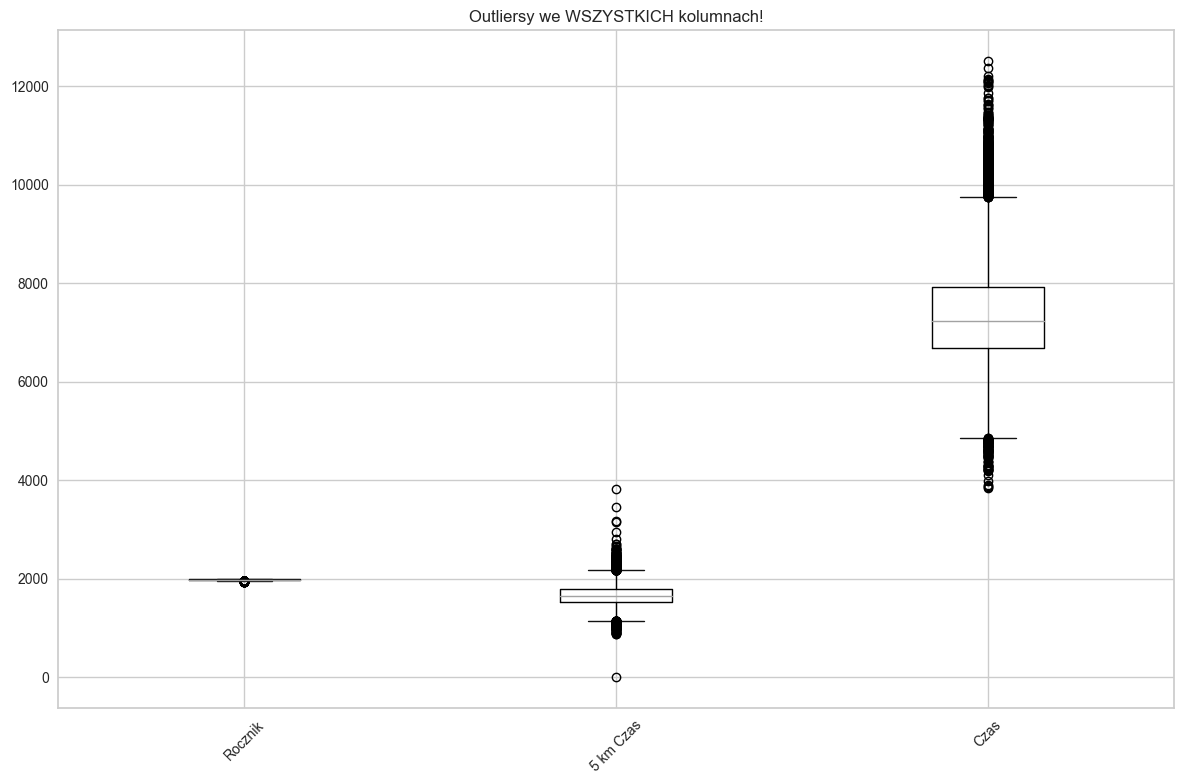

Liczba outliersów w każdej kolumnie:


NameError: name 'outliers' is not defined

In [16]:
# POKAŻ BOXPLOTY DLA WSZYSTKICH KOLUMN NARAZ!
df.boxplot(figsize=(12, 8))  # figsize = rozmiar okna
plt.xticks(rotation=45)      # Obróć nazwy kolumn
plt.title('Outliersy we WSZYSTKICH kolumnach!')
plt.tight_layout()
plt.show()


print("Liczba outliersów w każdej kolumnie:")
print(outliers)

In [17]:

# USUŃ outliersy Z WSZYSTKICH kolumn NARAZ!
def remove_outliers(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df = df.copy()
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Usuń wiersze gdzie TA kolumna jest outlierem
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    
    return df

# UŻYJ:
df_clean = remove_outliers(df)
print(f"Było: {len(df)} wierszy, Zostało: {len(df)}")

Było: 21441 wierszy, Zostało: 21441


In [15]:
Q1 = df["5 km Czas"].quantile(0.25)
Q3 = df["5 km Czas"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fake_no_outliers_df = df[~((df["5 km Czas"] < lower_bound) | (df["5 km Czas"] > upper_bound))]

In [43]:
df.to_csv('df.csv', index=False)

In [38]:
df = df[df['5 km Czas'] > 0]

In [39]:
print(df[df.duplicated(keep=False)])

      Płeć  Rocznik Kategoria wiekowa  5 km Czas    Czas
1786     M   1975.0               M40     1498.0  6397.0
3175     M   1987.0               M30     1572.0  6917.0
3779     M   1973.0               M50     1615.0  7118.0
3781     M   1973.0               M50     1615.0  7118.0
4057     M   1989.0               M30     1591.0  7196.0
...    ...      ...               ...        ...     ...
21952    K   1982.0               K40     1663.0  7256.0
21953    K   1998.0               K20     1663.0  7256.0
21954    M   1995.0               M20     1663.0  7256.0
21955    K   1991.0               K30     1663.0  7256.0
21956    M   1988.0               M30     1663.0  7256.0

[3505 rows x 5 columns]


In [18]:
df = df.drop_duplicates()

# Od tego momentu jest prawie kopia z linku: https://github.com/vanderveltz/halfmarathon-app/blob/main/training_pipeline.ipyn


In [20]:
def clean_dataframe(df: pd.DataFrame, race_year: int) -> pd.DataFrame:
    df = df.copy()

    # ── Czas ukończenia ────────────────────────────────────────────
    df['Czas_s'] = df['Czas'].apply(convert_time_to_seconds)

    # ── Tempo na 5 km ──────────────────────────────────────────────
    # Kolumna '5 km Tempo' już jest w min/km jako float
    df['tempo_5km'] = pd.to_numeric(df['5 km Tempo'], errors='coerce')

    # ── Płeć ───────────────────────────────────────────────────────
    df['plec'] = df['Płeć'].map({'M': 0, 'K': 1})

    # ── Wiek ───────────────────────────────────────────────────────
    df['rocznik'] = pd.to_numeric(df['Rocznik'], errors='coerce')
    df['wiek'] = race_year - df['rocznik']

    # ── Filtrowanie ────────────────────────────────────────────────
    df = df.dropna(subset=['Czas_s', 'tempo_5km', 'plec', 'wiek'])

    # Usuwamy wartości odstające (ukończenie między 55 min a 4h)
    df = df[(df['Czas_s'] >= 3300) & (df['Czas_s'] <= 14400)]
    # Wiek rozsądny
    df = df[(df['wiek'] >= 15) & (df['wiek'] <= 90)]
    # Tempo 5km rozsądne (2.5 – 15 min/km)
    df = df[(df['tempo_5km'] >= 2.5) & (df['tempo_5km'] <= 15)]

    return df[['plec', 'wiek', 'tempo_5km', 'Czas_s']]


df_2023_clean = clean_dataframe(df_2023, 2023)
df_2024_clean = clean_dataframe(df_2024, 2024)

df_all = pd.concat([df_2023_clean, df_2024_clean], ignore_index=True)

print(f'📊 Łącznie po czyszczeniu: {len(df_all)} rekordów')
print(df_all.describe())

📊 Łącznie po czyszczeniu: 17908 rekordów
               plec          wiek     tempo_5km        Czas_s
count  17908.000000  17908.000000  17908.000000  17908.000000
mean       0.288474     39.181986      5.574601   7391.771945
std        0.453066     10.232059      0.821511   1211.286563
min        0.000000     17.000000      2.923333   3843.000000
25%        0.000000     32.000000      5.002500   6544.000000
50%        0.000000     39.000000      5.533333   7240.000000
75%        1.000000     46.000000      6.110000   8127.250000
max        1.000000     89.000000     12.750000  12512.000000


In [22]:
raw_exp=setup(
    data=df_all,
    target="Czas_s",
    verbose=False,
    session_id=234
)
raw_best_model=raw_exp.compare_models()
raw_metrics_df


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,298.5976,171180.1438,413.2549,0.8840,0.0521,0.0390,1.3940
lightgbm,Light Gradient Boosting Machine,301.6900,174836.1298,417.7126,0.8815,0.0527,0.0394,0.7980
lasso,Lasso Regression,301.1928,179839.8656,423.4740,0.8780,0.0527,0.0393,0.0720
ridge,Ridge Regression,301.1931,179846.4609,423.4803,0.8780,0.0527,0.0393,0.0520
lar,Least Angle Regression,301.1903,179846.5109,423.4803,0.8780,0.0527,0.0393,0.0650
llar,Lasso Least Angle Regression,301.1929,179839.9266,423.4741,0.8780,0.0527,0.0393,0.0630
omp,Orthogonal Matching Pursuit,301.3101,179927.3109,423.5727,0.8780,0.0527,0.0393,0.0490
br,Bayesian Ridge,301.1910,179846.4922,423.4803,0.8780,0.0527,0.0393,0.0700
lr,Linear Regression,301.1903,179846.4969,423.4802,0.8780,0.0527,0.0393,10.9930
huber,Huber Regressor,296.5094,182359.6099,426.4239,0.8764,0.0529,0.0384,0.2620


NameError: name 'raw_metrics_df' is not defined

In [21]:

plot_model(best, plot='error')

NameError: name 'best' is not defined

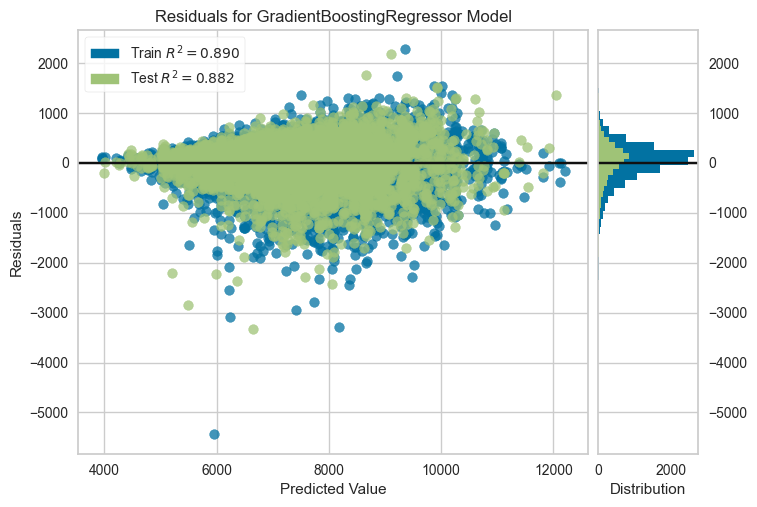

In [32]:
plot_model(best, plot='residuals')

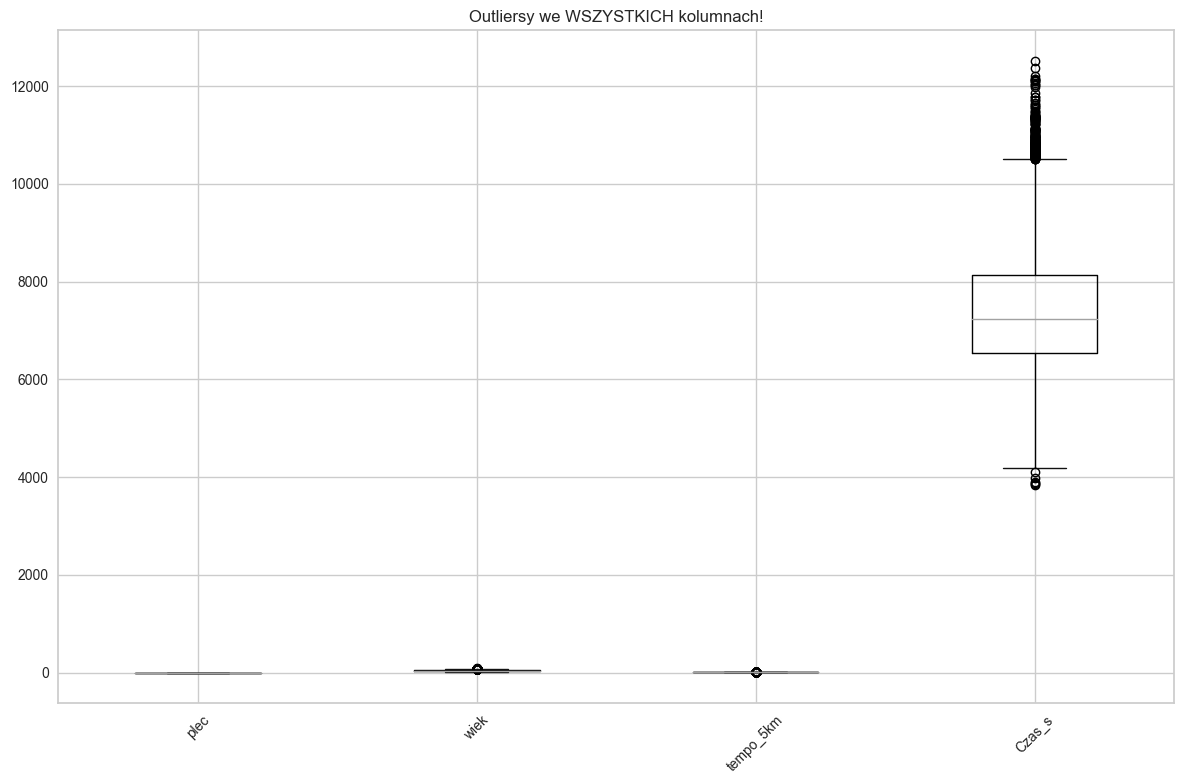

Liczba outliersów w każdej kolumnie:


NameError: name 'outliers' is not defined

In [22]:
# POKAŻ BOXPLOTY DLA WSZYSTKICH KOLUMN NARAZ!
df_all.boxplot(figsize=(12, 8))  # figsize = rozmiar okna
plt.xticks(rotation=45)      # Obróć nazwy kolumn
plt.title('Outliersy we WSZYSTKICH kolumnach!')
plt.tight_layout()
plt.show()


print("Liczba outliersów w każdej kolumnie:")
print(outliers)

In [29]:
df_all.describe()
df_all

,plec,wiek,tempo_5km,Czas_s
0,0.0,31.0,2.923333,3899.0
1,0.0,37.0,2.960000,3983.0
2,0.0,27.0,3.153333,4104.0
3,0.0,35.0,3.236667,4216.0
4,0.0,28.0,3.240000,4227.0
...,...,...,...,...
17903,1.0,47.0,7.986667,11866.0
17904,1.0,76.0,8.700000,11987.0
17905,1.0,46.0,8.420000,12068.0
17906,1.0,69.0,9.866667,12138.0


In [34]:
def clean_dataframe(df: pd.DataFrame, race_year: int) -> pd.DataFrame:
    # Tworzymy kopię danych, aby nie zepsuć oryginału
    df = df.copy()

    # ── Czas ukończenia ────────────────────────────────────────────
    # W Twoim pliku 'Czas' jest już podany w sekundach (super wygoda!)
    df['Czas_s'] = df['Czas']

    # ── Tempo na 5 km ──────────────────────────────────────────────
    # Mamy kolumnę '5 km Czas' (w sekundach). Aby mieć min/km, robimy prostą matematykę:
    # 1. Dzielimy przez 5 (aby mieć sekundy na 1 kilometr)
    # 2. Dzielimy przez 60 (aby zamienić sekundy na minuty)
    df['tempo_5km'] = (df['5 km Czas'] / 5) / 60

    # ── Płeć ───────────────────────────────────────────────────────
    # Zamieniamy literki M i K na 0 i 1 (czyli to, co lubi sztuczna inteligencja)
    df['plec'] = df['Płeć'].map({'M': 0, 'K': 1})

    # ── Wiek ───────────────────────────────────────────────────────
    df['rocznik'] = pd.to_numeric(df['Rocznik'], errors='coerce')
    df['wiek'] = race_year - df['rocznik']

    # ── Filtrowanie ────────────────────────────────────────────────
    # Najpierw wyrzucamy wiersze, które mogłyby nie mieć podstawowych danych
    df = df.dropna(subset=['Czas_s', 'tempo_5km', 'plec', 'wiek'])

    # Usuwamy wartości odstające: czas całkowity między 55 min a 4h
    df = df[(df['Czas_s'] >= 3300) & (df['Czas_s'] <= 14400)]
    
    # Wiek rozsądny: od 15 do 90 lat
    df = df[(df['wiek'] >= 15) & (df['wiek'] <= 90)]
    
    # Tempo rozsądne: od 2.5 min/km (światowa elita) do 15 min/km (bardzo powolny spacer)
    df = df[(df['tempo_5km'] >= 2.5) & (df['tempo_5km'] <= 15)]

    # Zwracamy pięknie wyczyszczoną ramkę z czterema kolumnami do uczenia modelu
    return df[['plec', 'wiek', 'tempo_5km', 'Czas_s']]

# ---- Jak użyć tego kodu do Twojego pliku: ----

# Wczytujemy Twój oryginalny plik
df_raw = pd.read_csv('df.csv')

# Czyścimy dane (zakładając, że to bieg np. z 2024 roku)
df_clean = clean_dataframe(df_raw, race_year=2024)

# Sprawdzamy efekt
print(f'📊 Łącznie przed czyszczeniem: {len(df_raw)} rekordów')
print(f'📊 Łącznie po czyszczeniu: {len(df_clean)} rekordów')

KeyError: 'Czas'

In [22]:
raw_exp=setup(
    data=df_all,
    target="Czas_s",
    verbose=False,
    session_id=234
)
raw_best_model=raw_exp.compare_models()
raw_metrics_df


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,296.7882,167136.4360,408.6324,0.8860,0.0519,0.0388,0.5450
lightgbm,Light Gradient Boosting Machine,300.1385,170701.8907,412.9317,0.8836,0.0524,0.0393,0.2100
lasso,Lasso Regression,299.0493,174561.0453,417.3238,0.8810,0.0523,0.0391,0.0290
ridge,Ridge Regression,299.0541,174558.6781,417.3204,0.8810,0.0523,0.0391,0.0430
lar,Least Angle Regression,299.0513,174558.7141,417.3202,0.8810,0.0523,0.0391,0.0450
llar,Lasso Least Angle Regression,299.0494,174561.0609,417.3238,0.8810,0.0523,0.0391,0.0490
omp,Orthogonal Matching Pursuit,299.1233,174655.4375,417.4360,0.8810,0.0523,0.0391,0.0290
br,Bayesian Ridge,299.0521,174558.7188,417.3203,0.8810,0.0523,0.0391,0.0300
lr,Linear Regression,299.0513,174558.7062,417.3202,0.8810,0.0523,0.0391,1.4150
huber,Huber Regressor,294.3276,177219.8931,420.4912,0.8792,0.0526,0.0381,0.1010


NameError: name 'raw_metrics_df' is not defined

# sprobujemy to z tuningowac, kod z lekcji normalizacja standaryzacja, to ma niby polepszyc dzwon gausowski

In [26]:
transformed_exp = setup(
    data=df_all,
    target='Czas_s',
    verbose=False,
    transformation=True,
    transformation_method='yeo-johnson',
    session_id=123,
)
best_transformed_model = transformed_exp.compare_models()
transformed_metrics_df = pull()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,297.0456,166994.1505,408.5460,0.8865,0.0516,0.0388,0.7650
lightgbm,Light Gradient Boosting Machine,299.3279,169133.8225,411.1437,0.8850,0.0520,0.0392,0.3400
lasso,Lasso Regression,311.4322,177505.0344,421.2219,0.8794,0.0539,0.0411,0.1420
ridge,Ridge Regression,311.5411,177501.0672,421.2174,0.8794,0.0540,0.0411,0.1470
lar,Least Angle Regression,311.6452,177498.0875,421.2142,0.8794,0.0540,0.0412,0.1210
llar,Lasso Least Angle Regression,311.4323,177505.0438,421.2219,0.8794,0.0539,0.0411,0.1980
br,Bayesian Ridge,311.6432,177498.0672,421.2142,0.8794,0.0540,0.0412,0.1230
lr,Linear Regression,311.6452,177498.1000,421.2142,0.8794,0.0540,0.0412,0.2070
omp,Orthogonal Matching Pursuit,311.8436,177600.3172,421.3372,0.8793,0.0540,0.0412,0.1180
huber,Huber Regressor,306.3563,181148.8410,425.5205,0.8769,0.0540,0.0400,0.2480


NameError: name 'pull' is not defined

In [34]:
df_all.describe()

,plec,wiek,tempo_5km,Czas_s
count,17903.000000,17903.000000,17903.000000,17903.000000
mean,0.288387,39.181590,5.574399,7391.476456
std,0.453025,10.232846,0.821463,1211.210400
min,0.000000,17.000000,2.923333,3843.000000
25%,0.000000,32.000000,5.000000,6543.500000
50%,0.000000,39.000000,5.530000,7239.000000
75%,1.000000,46.000000,6.110000,8127.000000
max,1.000000,89.000000,12.750000,12512.000000


In [43]:
df_all.to_csv('df_all.csv', index=False)

In [40]:
print(df_all[df_all.duplicated(keep=False)])

NameError: name 'df_all' is not defined

In [25]:
df_all = df_all.drop_duplicates()

In [27]:
tuned_model = transformed_exp.tune_model(best_transformed_model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,322.5896,192724.5869,439.0041,0.8757,0.0550,0.0423
1,304.0848,179183.1424,423.3003,0.8684,0.0543,0.0400
2,316.6550,199197.4735,446.3154,0.8578,0.0555,0.0409
3,306.4869,171733.6109,414.4075,0.8778,0.0529,0.0402
4,312.9769,176762.5553,420.4314,0.8830,0.0531,0.0411
5,310.8993,185135.4791,430.2737,0.8733,0.0540,0.0406
6,329.4299,204271.3740,451.9639,0.8635,0.0560,0.0424
7,306.5605,192187.6835,438.3922,0.8737,0.0552,0.0399
8,321.6103,196595.1034,443.3905,0.8660,0.0556,0.0418


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


# atu sprobuje zrobic wersje z dodatkowa kolumna , z wynikami na 10 km jak sugerowal czat. Tuninigowanie nie pomoglo, potuningu wyniki sa gorsze niz przed.

In [41]:
def clean_dataframe(df: pd.DataFrame, race_year: int) -> pd.DataFrame:
    df = df.copy()

    # ── Czas ukończenia ────────────────────────────────────────────
    df['Czas_s'] = df['Czas'].apply(convert_time_to_seconds)

    # ── Tempo na 5 km ──────────────────────────────────────────────
    # Kolumna '5 km Tempo' już jest w min/km jako float
    df['tempo_5km'] = pd.to_numeric(df['5 km Tempo'], errors='coerce')
    df['tempo_5km'] = pd.to_numeric(df['5 km Tempo'], errors='coerce')

    # ── Płeć ───────────────────────────────────────────────────────
    df['plec'] = df['Płeć'].map({'M': 0, 'K': 1})

    # ── Wiek ───────────────────────────────────────────────────────
    df['rocznik'] = pd.to_numeric(df['Rocznik'], errors='coerce')
    df['wiek'] = race_year - df['rocznik']

    # ── Filtrowanie ────────────────────────────────────────────────
    df = df.dropna(subset=['Czas_s', 'tempo_5km', 'plec', 'wiek'])

    # Usuwamy wartości odstające (ukończenie między 55 min a 4h)
    df = df[(df['Czas_s'] >= 3300) & (df['Czas_s'] <= 14400)]
    # Wiek rozsądny
    df = df[(df['wiek'] >= 15) & (df['wiek'] <= 90)]
    # Tempo 5km rozsądne (2.5 – 15 min/km)
    df = df[(df['tempo_5km'] >= 2.5) & (df['tempo_5km'] <= 15)]

    return df[['plec', 'wiek', 'tempo_5km', 'Czas_s']]


df_2023_clean = clean_dataframe(df_2023, 2023)
df_2024_clean = clean_dataframe(df_2024, 2024)

df_all = pd.concat([df_2023_clean, df_2024_clean], ignore_index=True)

print(f'📊 Łącznie po czyszczeniu: {len(df_all)} rekordów')
print(df_all.describe())

📊 Łącznie po czyszczeniu: 17908 rekordów
               plec          wiek     tempo_5km        Czas_s
count  17908.000000  17908.000000  17908.000000  17908.000000
mean       0.288474     39.181986      5.574601   7391.771945
std        0.453066     10.232059      0.821511   1211.286563
min        0.000000     17.000000      2.923333   3843.000000
25%        0.000000     32.000000      5.002500   6544.000000
50%        0.000000     39.000000      5.533333   7240.000000
75%        1.000000     46.000000      6.110000   8127.250000
max        1.000000     89.000000     12.750000  12512.000000


In [30]:
df.to_csv('df10.csv', index=False)

In [42]:
df10 = pd.read_csv('df10.csv')

In [43]:
def clean_dataframe_v2(df: pd.DataFrame, race_year: int) -> pd.DataFrame:
    df = df.copy()

    # Czas ukończenia (już w sekundach)
    df['Czas_s'] = df['Czas']

    # Tempo na 5 km (min/km)
    df['tempo_5km'] = (df['5 km Czas'] / 5) / 60

    # Tempo na 10 km (min/km) — NOWOŚĆ
    df['tempo_10km'] = (df['10 km Czas'] / 10) / 60

    # Nowa cecha: o ile zawodnik zwolnił między 5 a 10 km — NOWOŚĆ
    df['spadek_tempa'] = df['tempo_10km'] - df['tempo_5km']

    # Płeć: M=0, K=1
    df['plec'] = df['Płeć'].map({'M': 0, 'K': 1})

    # Wiek
    df['rocznik'] = pd.to_numeric(df['Rocznik'], errors='coerce')
    df['wiek'] = race_year - df['rocznik']

    # Usuwamy braki
    df = df.dropna(subset=['Czas_s', 'tempo_5km', 'tempo_10km', 'spadek_tempa', 'plec', 'wiek'])

    # Filtry rozsądnych wartości
    df = df[(df['Czas_s'] >= 3300) & (df['Czas_s'] <= 14400)]
    df = df[(df['wiek'] >= 15) & (df['wiek'] <= 90)]
    df = df[(df['tempo_5km'] >= 2.5) & (df['tempo_5km'] <= 15)]
    df = df[(df['tempo_10km'] >= 2.5) & (df['tempo_10km'] <= 15)]

    return df[['plec', 'wiek', 'tempo_5km', 'tempo_10km', 'spadek_tempa', 'Czas_s']]

# Użycie:
df10_clean = clean_dataframe_v2(df10, race_year=2024)

In [ ]:
# Krok 1: Konfiguracja eksperymentu na nowych danych
exp_10km = setup(
    data=df10_clean,
    target='Czas_s',
    verbose=False,
    transformation=True,
    transformation_method='yeo-johnson',
    session_id=123,
)

# Krok 2: Porównanie wszystkich modeli
best_10km_model = exp_10km.compare_models()

# Krok 3: Wyciągamy tabelę z wynikami do zmiennej
metrics_10km = pull()
print(metrics_10km)

# ── Krok 5: Zapisujemy najlepszy model do pliku ────────────────────
save_model(best_10km_

model, 'model_maratonu_10')
print("✅ Model zapisany jako 'model_maratonu_10.pkl'!")


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,168.2652,64475.6205,253.2004,0.9555,0.0321,0.0220,1.1540
lightgbm,Light Gradient Boosting Machine,170.3317,66034.5402,256.2825,0.9545,0.0326,0.0223,0.3890
rf,Random Forest Regressor,177.3939,71772.6014,267.3452,0.9505,0.0341,0.0233,16.8100
et,Extra Trees Regressor,182.1148,76013.3473,275.1505,0.9476,0.0350,0.0239,5.4280
lr,Linear Regression,186.9951,78350.4352,278.9275,0.9461,0.0358,0.0248,0.2910
lar,Least Angle Regression,186.9951,78349.9770,278.9267,0.9461,0.0358,0.0248,0.4940
br,Bayesian Ridge,187.0375,78347.4582,278.9225,0.9461,0.0358,0.0248,0.6480
lasso,Lasso Regression,190.3695,79436.3613,280.8096,0.9453,0.0365,0.0253,0.6890
llar,Lasso Least Angle Regression,190.3694,79436.3055,280.8095,0.9453,0.0365,0.0253,0.4570
ridge,Ridge Regression,190.4557,79713.7047,281.2418,0.9451,0.0369,0.0254,0.5570


                                    Model       MAE           MSE       RMSE  \
gbr           Gradient Boosting Regressor  168.2652  6.447562e+04   253.2004   
lightgbm  Light Gradient Boosting Machine  170.3317  6.603454e+04   256.2825   
rf                Random Forest Regressor  177.3939  7.177260e+04   267.3452   
et                  Extra Trees Regressor  182.1148  7.601335e+04   275.1505   
lr                      Linear Regression  186.9951  7.835044e+04   278.9275   
lar                Least Angle Regression  186.9951  7.834998e+04   278.9267   
br                         Bayesian Ridge  187.0375  7.834746e+04   278.9225   
lasso                    Lasso Regression  190.3695  7.943636e+04   280.8096   
llar         Lasso Least Angle Regression  190.3694  7.943631e+04   280.8095   
ridge                    Ridge Regression  190.4557  7.971370e+04   281.2418   
huber                     Huber Regressor  178.7648  8.511328e+04   290.0452   
knn                 K Neighbors Regresso

In [38]:
# Porównanie kluczowych metryk: stary model vs nowy
print("=== STARY MODEL (bez 10 km) ===")
print(f"R2: 0.8893  |  RMSE: 402 s  |  MAE: 297 s")

print("\n=== NOWY MODEL (z 10 km) ===")
print(f"R2: {metrics_10km.iloc[0]['R2']:.4f}  |  RMSE: {metrics_10km.iloc[0]['RMSE']:.0f} s  |  MAE: {metrics_10km.iloc[0]['MAE']:.0f} s")

=== STARY MODEL (bez 10 km) ===
R2: 0.8893  |  RMSE: 402 s  |  MAE: 297 s

=== NOWY MODEL (z 10 km) ===
R2: 0.9555  |  RMSE: 253 s  |  MAE: 168 s


# moldel z wynikami na 10 km ma lepsze wyniki, ale w budowie aplikacji musialbymw jakis spsosob uwzglednic te 10 . Czyli opcja ze uzytkownik podaje tylko czas na 5 km odpada. wiec musze kombinowac wersje na 5km. Na razie pozostaje praca z outlinerami

In [31]:


def process_outliers(df_all):
    """
    Groups the data by gender and age_category and removes 
    outliers based on the IQR method for the 'time' column.
    """
    
    # 2. Define the cleaning function for each group
    def clean_group(group):
        Q1 = group['time'].quantile(0.25)
        Q3 = group['time'].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Filtering data within the bounds
        return group[(group['time'] >= lower_bound) & (group['time'] <= upper_bound)]

    # 3. Apply the function per demographic group
    # group_keys=False keeps the original index structure
    df_cleaned = df.groupby(['gender', 'age_category'], group_keys=False).apply(clean_group)
    
    # Calculate statistics
    removed = len(df_all) - len(df_all)
    print(f"Original Records: {len(df_all)}")
    print(f"Cleaned Records: {len(df_all)}")
    print(f"Outliers Removed: {removed} ({removed/len(df_all):.2%})")
    
    return df_all



In [44]:
df_all.to_csv('df_all.csv', index=False)
print(f"Gotowe! Zapisano {len(df_all)} wierszy.")

Gotowe! Zapisano 17903 wierszy.


In [45]:
print(os.getcwd())  # To pokaże Ci w którym folderze pracuje Python

c:\Users\w\Desktop\od_zera_do_ai\projekty\moduł 9 marathon


In [46]:
# Sprawdzamy gdzie jesteśmy
print(f"Folder roboczy: {os.getcwd()}")

# Wczytujemy plik
df_all = pd.read_csv('df_all.csv')
print(f"Wczytano: {len(df_all)} wierszy, duplikaty: {df_all.duplicated().sum()}")

# Usuwamy duplikaty
df_all = df_all.drop_duplicates()
print(f"Po usunięciu: {len(df_all)} wierszy, duplikaty: {df_all.duplicated().sum()}")

# Zapisujemy
df_all.to_csv('df_all.csv', index=False)

# Weryfikacja - wczytujemy jeszcze raz żeby sprawdzić czy zapis zadziałał
df_check = pd.read_csv('df_all.csv')
print(f"Weryfikacja po zapisie: {len(df_check)} wierszy, duplikaty: {df_check.duplicated().sum()}")
print("✅ Gotowe!" if df_check.duplicated().sum() == 0 else "❌ Coś poszło nie tak!")

Folder roboczy: c:\Users\w\Desktop\od_zera_do_ai\projekty\moduł 9 marathon
Wczytano: 17903 wierszy, duplikaty: 0
Po usunięciu: 17903 wierszy, duplikaty: 0
Weryfikacja po zapisie: 17903 wierszy, duplikaty: 0
✅ Gotowe!


In [ ]:
exp = setup(
    data=df_all,
    target='Czas_s',
    verbose=False,
    transformation=True,
    transformation_method='yeo-johnson',
    session_id=123,
)

# ── Krok 3: Porównanie wszystkich modeli i wybór najlepszego ───────
best_model = compare_models()

# ── Krok 4: Wyciągamy tabelę z wynikami ───────────────────────────
metrics = pull()
print(metrics)

# ── Krok 5: Zapisujemy najlepszy model do pliku ────────────────────
save_model(best_model, 'model_maratonu')
print("✅ Model zapisany jako 'model_maratonu.pkl'!")


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,297.0456,166994.1505,408.5460,0.8865,0.0516,0.0388,1.0160
lightgbm,Light Gradient Boosting Machine,299.3279,169133.8225,411.1437,0.8850,0.0520,0.0392,0.5710
lasso,Lasso Regression,311.4322,177505.0344,421.2219,0.8794,0.0539,0.0411,0.1820
ridge,Ridge Regression,311.5411,177501.0672,421.2174,0.8794,0.0540,0.0411,0.6070
lar,Least Angle Regression,311.6452,177498.0875,421.2142,0.8794,0.0540,0.0412,0.1510
llar,Lasso Least Angle Regression,311.4323,177505.0438,421.2219,0.8794,0.0539,0.0411,0.1660
br,Bayesian Ridge,311.6432,177498.0672,421.2142,0.8794,0.0540,0.0412,0.2010
lr,Linear Regression,311.6452,177498.1000,421.2142,0.8794,0.0540,0.0412,3.1200
omp,Orthogonal Matching Pursuit,311.8436,177600.3172,421.3372,0.8793,0.0540,0.0412,0.1890
huber,Huber Regressor,306.3563,181148.8410,425.5205,0.8769,0.0540,0.0400,0.4640


                                    Model       MAE           MSE       RMSE  \
gbr           Gradient Boosting Regressor  297.0456  1.669942e+05   408.5460   
lightgbm  Light Gradient Boosting Machine  299.3279  1.691338e+05   411.1437   
lasso                    Lasso Regression  311.4322  1.775050e+05   421.2219   
ridge                    Ridge Regression  311.5411  1.775011e+05   421.2174   
lar                Least Angle Regression  311.6452  1.774981e+05   421.2142   
llar         Lasso Least Angle Regression  311.4323  1.775050e+05   421.2219   
br                         Bayesian Ridge  311.6432  1.774981e+05   421.2142   
lr                      Linear Regression  311.6452  1.774981e+05   421.2142   
omp           Orthogonal Matching Pursuit  311.8436  1.776003e+05   421.3372   
huber                     Huber Regressor  306.3563  1.811488e+05   425.5205   
par          Passive Aggressive Regressor  325.5859  1.897115e+05   435.3234   
knn                 K Neighbors Regresso